# MobGap Tutorial Experimental (CWA -> pipeline via mobgap.data.load_cwa_as_dataset)

This recreates `mobilise-d_mobgap_tutorial/mobgap_tutorial_johnny.py`, but loads `.cwa`
files directly with `mobgap.data.load_cwa_as_dataset` instead of converting to MATLAB first.

The plotting and pipeline sections follow the John Mitchell's tutorial as closely as possible.
Differences:
- Sensor columns use MobGap names (`acc_x`, `gyr_x`, ...) rather than `accel_x`, `gyro_x`, ...
- Acceleration is in m/s^2 (MobGap convention), not in g
- No intermediate `.mat` files are written, the CWA file goes straight into a dataset
- **Resampling:** this path uses MobGap's `Resample` (`scipy.signal.resample`), not the linear `numpy.interp` re-gridding in `get_cwa_data(resample=True)`. Pipeline outputs may therefore differ from `MobGap_Tutorial.ipynb` even on the same `.cwa` file. See `reports/cwa-to-mobgap-paths.md` §5. To skip MobGap's resampling step entirely, pass `resample_hz=None`.

In [1]:
import os

def get_paths_with_extension(extension):
    paths = []
    dataset_folder = os.path.join(os.getcwd())

    for root, dirs, files in os.walk(dataset_folder):
        for file in files:
            if file.lower().endswith(extension):
                path = os.path.join(root, file)
                if not ".venv" in path:
                    paths.append(path)

    return paths

cwa_files = get_paths_with_extension(".cwa")

print("Here is the list of all our \".cwa\" files:")
print(cwa_files)

Here is the list of all our ".cwa" files:
['/Users/artem/Work/n8-mobgap/mobilise-d_mobgap_tutorial/6032032_0000000000.cwa']


Now let's load the CWA file with MobGap's built-in loader.

`load_cwa_as_dataset` wraps the Open Movement reader, converts units/column names to MobGap
conventions, and returns a dataset that can be passed into MobGap pipeline.

We pass `resample_hz=100` below to match the nominal AX3 rate. That applies MobGap's Fourier
resampler — it does **not** replicate Johnny's tutorial, which always re-grids with linear
interpolation via `get_cwa_data(resample=True)`.

In [2]:
from datetime import datetime, timezone
from IPython.display import display

from mobgap.data import load_cwa_as_dataset

if len(cwa_files) > 1:
    print("Error, more than 1 \".cwa\" file in your folder, make sure you just have your file from today in there!")
elif len(cwa_files) == 0:
    raise FileNotFoundError("No .cwa file found in the current folder.")
else:
    participant_metadata = {
        "cohort": "HA",
        "height_m": 183 / 100,
        "sensor_height_m": 111 / 100,
        
        # optional
        "age": 26,
        "weight": 80.4,
        "gender": "M",
        "handedness": "R",
        "subject_id": 1,
    }

    # resample_hz=100: MobGap Fourier resampling (scipy), not get_cwa_data linear interp.
    # use resample_hz=None to keep the Open Movement decoder output unchanged.
    dataset = load_cwa_as_dataset(
        cwa_files[0],
        participant_metadata,
        recording_metadata={"measurement_condition": "laboratory"},
        include_time_index=True,  # utc unix seconds for plotting
        resample_hz=100,
    )

    datapoint = dataset[0]
    samples = datapoint.data_ss

# note that we use display to make things look nice in notebooks, rather than print.
# If you want to see why, try replacing the following "display" with "print"...
display(samples.head(10))

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z
time,,,,,,
1.754565e+09,-3.411737,13.153744,7.570466,-42.480469,70.373535,42.419434
1.754565e+09,-4.946421,15.016433,7.323863,-28.442383,92.346191,15.808105
1.754565e+09,-4.086902,15.066711,7.261614,-24.841309,94.116211,-26.123047
1.754565e+09,-2.746149,14.166491,7.134721,-13.671875,103.454590,-53.283691
1.754565e+09,-2.207454,13.093889,6.035782,-2.807617,115.905762,-63.842773
1.754565e+09,-0.909797,11.159374,4.774038,0.061035,115.661621,-63.354492
1.754565e+09,0.110133,9.682152,3.478775,3.784180,112.609863,-45.166016
1.754565e+09,0.086191,8.724471,2.264915,3.845215,103.576660,-16.418457
1.754565e+09,0.198719,8.164228,0.732626,9.704590,93.688965,10.314941


Great! Now let's plot the data to see what this actually looks like. If you want, you can also see what the other axes look like by swapping out "acc_x" for:
- acc_y
- acc_z
- gyr_x
- gyr_y
- gyr_z

As seen in the table above. The index is UTC Unix time in seconds (not a pandas `DatetimeIndex`, which can segfault on some HPC module stacks). For readable time axes, convert with `datetime.fromtimestamp` when plotting (see below).

<Axes: xlabel='time'>

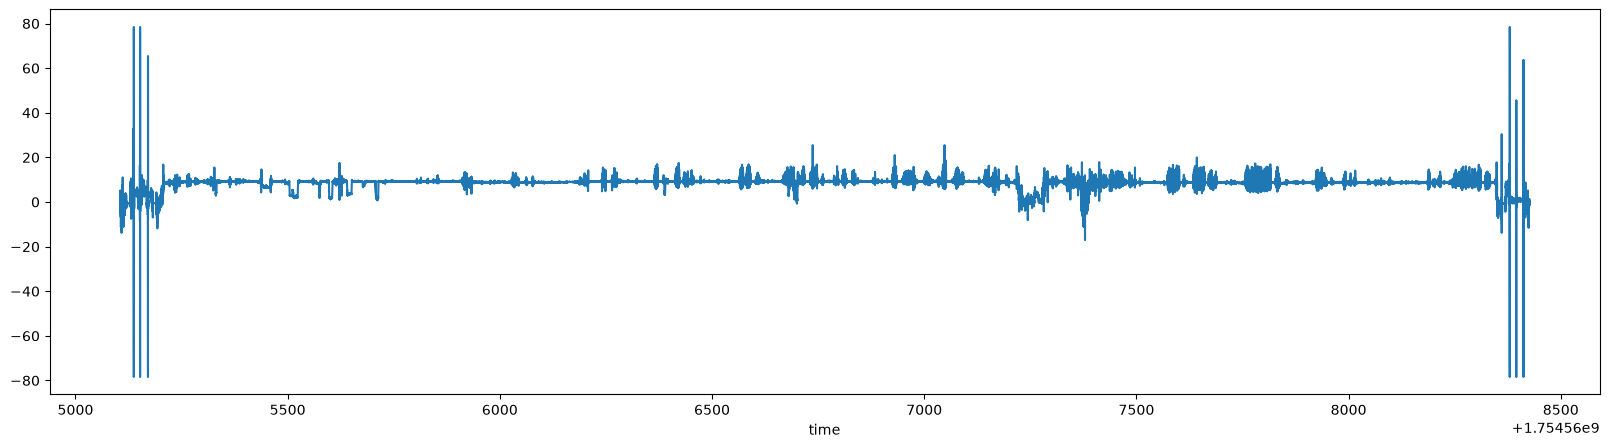

In [3]:
samples["acc_x"].plot(figsize=(20, 5))

We can be a bit smarter with our plots. If we use matplotlib, we can select a specific region of the data to plot. In the cell below, enter a start and end index (start_id and end_id) that you'd like to see and run the cell to see "acc_x" plotted against time so that we can see exactly when this data was recorded. Again we can change "acc_x" to any of the columns to see them plotted over time.

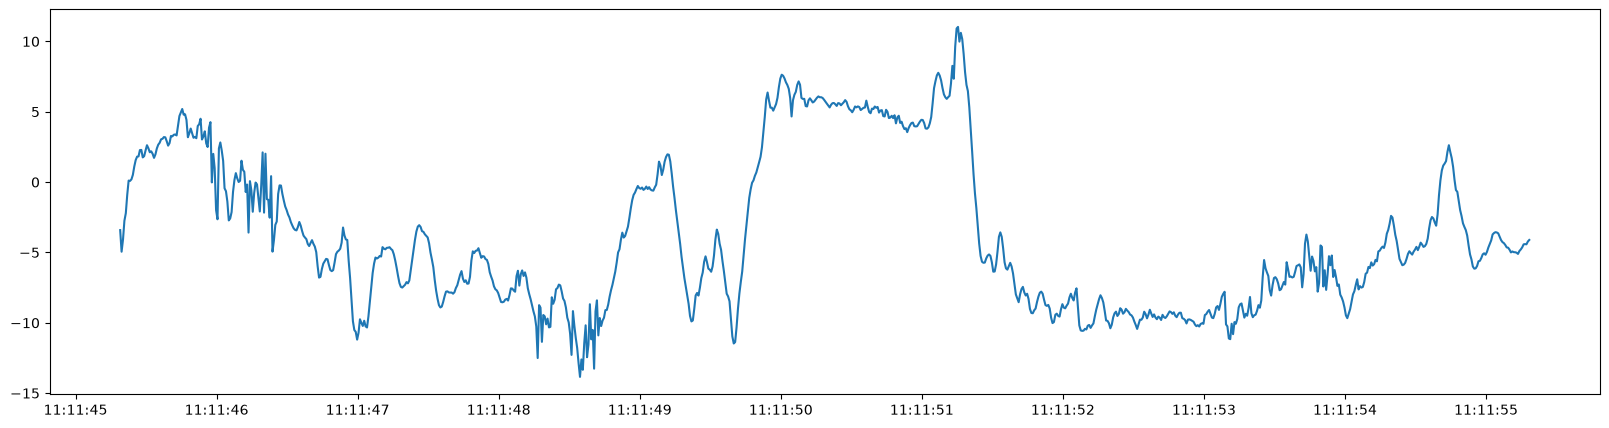

In [4]:
import matplotlib.pyplot as plt
from datetime import datetime, timezone

start_id = 0
end_id = 1000

samples_to_plot = samples.iloc[start_id:end_id]
time_axis = [datetime.fromtimestamp(t, tz=timezone.utc) for t in samples_to_plot.index]

plt.figure(figsize=(20, 5))
plt.plot(time_axis, samples_to_plot["acc_x"])
plt.show()

In Johnny's tutorial we converted timestamps to Unix time and built MATLAB structs before running MobGap.
With `load_cwa_as_dataset` that conversion happens internally, so we can skip straight to inspecting
the recording start time and sampling rate.

In [5]:
start_time_unix = datapoint.recording_metadata["cwa_start_time"]
start_date_time = datetime.fromtimestamp(start_time_unix, tz=timezone.utc).strftime("%d-%b-%Y %H:%M:%S")
print(start_date_time)

07-Aug-2025 11:11:45


Next we'll check our sample rate.

These sensors record 100 samples per second — 100 Hz. Printing `100` here does not mean the
waveform was re-gridded the same way as in Johnny's tutorial; see the resampling note above.

In [6]:
fs = datapoint.sampling_rate_hz
print(fs)

100


Skipping `.mat` files step since the dataset is in already in the format expected by MobGap pipeline.

In [7]:
print(dataset)

GaitDatasetFromData [1 groups/rows]

            recording_id
   0  6032032_0000000000


In [8]:
from mobgap.pipeline import MobilisedPipelineHealthy

pipeline = MobilisedPipelineHealthy()
pipeline = pipeline.safe_run(dataset)
print("Pipeline finished running!")

/Users/artem/Work/n8-mobgap/mobilise-d_mobgap_tutorial/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/artem/Work/n8-mobgap/mobilise-d_mobgap_tutorial/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/artem/Work/n8-mobgap/mobilise-d_mobgap_tutorial/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVers

Pipeline finished running!


In [9]:
display(pipeline.aggregated_parameters_)

,wb_all__count,total_walking_duration_min,wb_all__n_raw_initial_contacts__sum,wb_all__duration_s__avg,wb_all__duration_s__p90,wb_all__duration_s__var,wb_all__cadence_spm__avg,wb_all__stride_duration_s__avg,wb_all__cadence_spm__var,wb_all__stride_duration_s__var,...,wb_30__count,wb_30__walking_speed_mps__avg,wb_30__stride_length_m__avg,wb_30__cadence_spm__avg,wb_30__stride_duration_s__avg,wb_30__walking_speed_mps__p90,wb_30__cadence_spm__p90,wb_30__walking_speed_mps__var,wb_30__stride_length_m__var,wb_60__count
all_wbs,48,10.221333,935,9.75,26.058,0.784912,84.937908,1.281919,0.116938,0.153268,...,2,0.946486,1.191954,93.195911,1.218777,1.128594,100.631043,0.340125,0.210325,1


In [10]:
display(pipeline.per_wb_parameters_.head(5))

,start,end,n_strides,rule_name,rule_obj,duration_s,n_raw_initial_contacts,stride_duration_s,cadence_spm,stride_length_m,walking_speed_mps
wb_id,,,,,,,,,,,
0,92182,93395,14,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",12.13,16,1.527143,71.433869,0.946847,0.580721
1,97000,97422,5,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",4.22,7,1.374000,68.541983,0.568136,0.340453
2,108318,108725,4,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",4.07,6,1.687500,73.310649,0.825835,0.496100
3,109078,109588,4,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",5.10,6,1.475000,65.018471,0.765482,0.432201
4,113602,114385,10,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",7.83,12,1.170000,87.255415,1.173126,0.875892


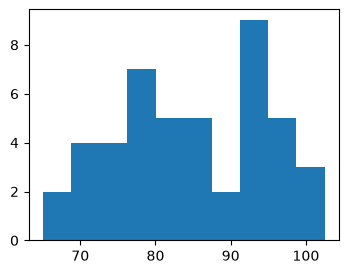

In [11]:
plt.figure(figsize=(4, 3))
plt.hist(pipeline.per_wb_parameters_["cadence_spm"], bins=10)
plt.show()